In [1]:
import pandas as pd

#import matplotlib.pyplot as plt

df = pd.read_csv("MOVIES DATASET FOR FEATURE EXTRACION ,PREDICTION.csv")
df.head(1000)

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
995,Kaze tachinu,(2013),"\nAnimation, Biography, Drama",7.8,"\nA look at the life of Jiro Horikoshi, the ma...",\n Director:\nHayao Miyazaki\n| \n Stars...,"77,732",126.0,$5.21M
996,Monster,(II) (2018),"\nCrime, Drama",6.5,"\nA smart, likeable, 17-year-old film student ...",\n Director:\nAnthony Mandler\n| \n Star...,"4,559",98.0,NaN
997,The Boss Baby: Back in Business,(2018–2021),"\nAnimation, Adventure, Comedy",6.5,\nWith a little help from his brother and acco...,"\n \n Stars:\nJP Karliak, \nDavi...","2,948",25.0,NaN
998,Spinning Out,(2020),"\nDrama, Sport",7.6,\nA figure skating Olympic hopeful's struggle ...,"\n \n Stars:\nKaya Scodelario, \...","11,776",48.0,NaN


In [2]:
df.shape

(9999, 9)

In [3]:
df.sample()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
5265,Chasing Cameron,(2016– ),\nReality-TV,3.7,"\nThe series centers around Cameron Dallas, a ...","\n \n Stars:\nTrey Schafer, \nLe...",490,31.0,NaN


In [4]:
df.describe()

,RATING,RunTime
count,8179.000000,7041.000000
mean,6.921176,68.688539
std,1.220232,47.258056
min,1.100000,1.000000
25%,6.200000,36.000000
50%,7.100000,60.000000
75%,7.800000,95.000000
max,9.900000,853.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [6]:
# See the original values first
df['YEAR'].head(20)

0          (2021)
1        (2021– )
2     (2010–2022)
3        (2013– )
4          (2021)
5        (2020– )
6          (2021)
7     (2006–2013)
8        (2020– )
9        (2019– )
10         (2021)
11    (2016–2021)
12         (2021)
13       (2021– )
14       (2011– )
15       (2005– )
16    (2008–2013)
17       (2017– )
18    (2017–2021)
19       (2016– )
Name: YEAR, dtype: object

In [7]:
import numpy as np

df['Release_Type'] = np.where(
    df['YEAR'].str.contains('–|-', na=False),
    'Series',
    'Movie'
)

In [8]:
df['Start_Year'] = (
    df['YEAR']
    .astype('string')
    .str.extract(r'(\d{4})', expand=False)
    .astype('Int64')
)

df['Start_Year'] = df['Start_Year'].fillna(1945)

df[['YEAR', 'Start_Year']].head(5)

,YEAR,Start_Year
0,(2021),2021
1,(2021– ),2021
2,(2010–2022),2010
3,(2013– ),2013
4,(2021),2021


In [9]:
df['Start_Year'].unique()

<IntegerArray>
[2021, 2010, 2013, 2020, 2006, 2019, 2016, 2011, 2005, 2008, 2017, 1994, 2014,
 2015, 2003, 2009, 2018, 1987, 2012, 2007, 2000, 1993, 1999, 2001, 1997, 1989,
 1975, 1995, 1984, 1998, 1966, 1990, 2002, 1976, 1978, 2022, 1982, 1968, 2004,
 1996, 1971, 1980, 1962, 1991, 1960, 1988, 1969, 1961, 1979, 1956, 1983, 1945,
 1986, 1967, 1974, 1992, 1958, 1932, 1941, 1950, 1946, 1981, 1952, 1957, 1954,
 1955, 1948, 1947, 1977, 2023, 1953, 1985, 1973, 1972, 1965, 1944, 1933, 1938]
Length: 78, dtype: Int64

In [10]:
df['End_Year'] = (
    df['YEAR']
    .astype('string')
    .str.extract(r'(\d{4})', expand=False)
    .astype('Int64')
)

df['End_Year'] = df['End_Year'].fillna(2025)

df[['YEAR', 'End_Year']].head(5)

,YEAR,End_Year
0,(2021),2021
1,(2021– ),2021
2,(2010–2022),2010
3,(2013– ),2013
4,(2021),2021


In [11]:
df['End_Year'].unique()

<IntegerArray>
[2021, 2010, 2013, 2020, 2006, 2019, 2016, 2011, 2005, 2008, 2017, 1994, 2014,
 2015, 2003, 2009, 2018, 1987, 2012, 2007, 2000, 1993, 1999, 2001, 1997, 1989,
 1975, 1995, 1984, 1998, 1966, 1990, 2002, 1976, 1978, 2022, 1982, 1968, 2004,
 1996, 1971, 1980, 1962, 1991, 1960, 1988, 1969, 1961, 1979, 1956, 1983, 2025,
 1986, 1967, 1974, 1992, 1958, 1932, 1941, 1950, 1946, 1981, 1952, 1957, 1954,
 1955, 1948, 1947, 1977, 2023, 1945, 1953, 1985, 1973, 1972, 1965, 1944, 1933,
 1938]
Length: 79, dtype: Int64

In [12]:
df.head(5)

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Release_Type,Start_Year,End_Year
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN,Movie,2021,2021
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN,Series,2021,2021
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN,Series,2010,2010
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN,Series,2013,2013
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN,Movie,2021,2021


In [13]:
df['YEAR'].unique()

array(['(2021)', '(2021– )', '(2010–2022)', '(2013– )', '(2020– )',
       '(2006–2013)', '(2019– )', '(2016–2021)', '(2011– )', '(2005– )',
       '(2008–2013)', '(2017– )', '(2017–2021)', '(2016– )',
       '(1994–2004)', '(2014– )', '(2013–2020)', '(2015– )',
       '(2005–2020)', '(2013–2022)', '(2003– )', '(2009–2020)',
       '(I) (2018– )', '(2010–2015)', '(2011–2019)', '(2015–2020)',
       '(2005–2014)', '(2009–2015)', '(2008–2014)', '(2016–2018)',
       '(2009–2017)', '(2020)', '(2018–2021)', '(2017–2020)',
       '(1987–1994)', '(2018– )', '(2012– )', '(2014–2020)',
       '(2011–2018)', '(2005–2017)', '(2017)', '(2007–2015)',
       '(2000–2007)', '(II) (2007– )', '(1993)', '(1999–2022)',
       '(2015–2018)', '(2014–2019)', '(2016)', '(2012–2020)',
       '(2013–2019)', '(2007–2012)', '(2011–2020)', '(2010–2017)',
       '(2000–2015)', '(2015–2021)', '(2001)', '(1997– )', '(2011–2017)',
       '(1993–1999)', '(1989–1998)', '(2010–2013)', '(2010–2020)',
       '(2003–2019)

In [14]:
df['GENRE'].unique()

array(['\nAction, Horror, Thriller            ',
       '\nAnimation, Action, Adventure            ',
       '\nDrama, Horror, Thriller            ',
       '\nAnimation, Adventure, Comedy            ',
       '\nAction, Crime, Horror            ',
       '\nAction, Crime, Drama            ',
       '\nDrama, Romance            ',
       '\nCrime, Drama, Mystery            ', '\nComedy            ',
       '\nAction, Adventure, Thriller            ',
       '\nCrime, Drama, Fantasy            ',
       '\nDrama, Horror, Mystery            ',
       '\nComedy, Drama, Romance            ',
       '\nCrime, Drama, Thriller            ', '\nDrama            ',
       '\nComedy, Drama            ',
       '\nDrama, Fantasy, Horror            ',
       '\nComedy, Romance            ',
       '\nAction, Adventure, Drama            ',
       '\nCrime, Drama            ',
       '\nDrama, History, Romance            ',
       '\nHorror, Mystery            ', '\nComedy, Crime            ',
     

In [15]:
df['GENRE'] = df['GENRE'].str.strip()

In [16]:
df['GENRE'].unique()

array(['Action, Horror, Thriller', 'Animation, Action, Adventure',
       'Drama, Horror, Thriller', 'Animation, Adventure, Comedy',
       'Action, Crime, Horror', 'Action, Crime, Drama', 'Drama, Romance',
       'Crime, Drama, Mystery', 'Comedy', 'Action, Adventure, Thriller',
       'Crime, Drama, Fantasy', 'Drama, Horror, Mystery',
       'Comedy, Drama, Romance', 'Crime, Drama, Thriller', 'Drama',
       'Comedy, Drama', 'Drama, Fantasy, Horror', 'Comedy, Romance',
       'Action, Adventure, Drama', 'Crime, Drama',
       'Drama, History, Romance', 'Horror, Mystery', 'Comedy, Crime',
       'Action, Drama, History', 'Action, Adventure, Crime',
       'Action, Adventure, Fantasy', 'Action, Crime, Mystery',
       'Drama, Fantasy, Romance', 'Drama, Sci-Fi, Thriller',
       'Biography, Drama, History', 'Crime, Thriller',
       'Comedy, Crime, Drama', 'Drama, Mystery, Thriller',
       'Action, Adventure, Mystery', 'Action, Comedy',
       'Crime, Drama, Horror', 'Drama, Mystery, Sc

In [17]:
df[['GENRE']].head(5)

,GENRE
0,"Action, Horror, Thriller"
1,"Animation, Action, Adventure"
2,"Drama, Horror, Thriller"
3,"Animation, Adventure, Comedy"
4,"Action, Crime, Horror"


In [18]:
df['GENRE'].isna().sum()

np.int64(80)

In [19]:
df[df['GENRE'].isna()]

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Release_Type,Start_Year,End_Year
2124,Rodney & Sheryl,NaN,NaN,NaN,\nBased on the unbelievable true story of seri...,\n Director:\nChloe Okuno\n| \n Star:\nA...,NaN,NaN,NaN,Movie,1945,2025
3144,Our Man from Jersey,NaN,NaN,NaN,\nAdd a Plot\n,"\n \n Stars:\nMark Wahlberg, \nH...",NaN,NaN,NaN,Movie,1945,2025
3433,The Upper World,NaN,NaN,NaN,\nEsso is caught in a deadly feud and on the v...,\n \n Star:\nDaniel Kaluuya\n,NaN,NaN,NaN,Movie,1945,2025
3695,Kod Adi: Kulüp,(2021– ),NaN,NaN,\nAdd a Plot\n,"\n \n Stars:\nGökçe Bahadir, \nB...",NaN,NaN,NaN,Series,2021,2021
4039,Oompa-Loompas,NaN,NaN,NaN,\nTV series centering on the adventures of the...,\n,NaN,NaN,NaN,Movie,1945,2025
...,...,...,...,...,...,...,...,...,...,...,...,...
6453,Untitled Tituss Burgess/Netflix Project,NaN,NaN,NaN,\nPlot under wraps.,\n,NaN,NaN,NaN,Movie,1945,2025
6461,One Piece: Enter Chopper at the Winter Island,(2020 TV Movie),NaN,NaN,\nAdd a Plot\n,\n,NaN,NaN,NaN,Movie,2020,2020
8769,Rádio Coisa Mais Linda,(2020),NaN,NaN,\nAdd a Plot\n,\n Director:\nCaito Ortiz\n| \n Stars:\n...,NaN,NaN,NaN,Movie,2020,2020
8770,Rádio Coisa Mais Linda,(2020),NaN,NaN,\nAdd a Plot\n,\n Director:\nCaito Ortiz\n| \n Stars:\n...,NaN,NaN,NaN,Movie,2020,2020


In [20]:
df['GENRE'] = df['GENRE'].fillna('African_History')

In [21]:
df['GENRE'].unique()

array(['Action, Horror, Thriller', 'Animation, Action, Adventure',
       'Drama, Horror, Thriller', 'Animation, Adventure, Comedy',
       'Action, Crime, Horror', 'Action, Crime, Drama', 'Drama, Romance',
       'Crime, Drama, Mystery', 'Comedy', 'Action, Adventure, Thriller',
       'Crime, Drama, Fantasy', 'Drama, Horror, Mystery',
       'Comedy, Drama, Romance', 'Crime, Drama, Thriller', 'Drama',
       'Comedy, Drama', 'Drama, Fantasy, Horror', 'Comedy, Romance',
       'Action, Adventure, Drama', 'Crime, Drama',
       'Drama, History, Romance', 'Horror, Mystery', 'Comedy, Crime',
       'Action, Drama, History', 'Action, Adventure, Crime',
       'Action, Adventure, Fantasy', 'Action, Crime, Mystery',
       'Drama, Fantasy, Romance', 'Drama, Sci-Fi, Thriller',
       'Biography, Drama, History', 'Crime, Thriller',
       'Comedy, Crime, Drama', 'Drama, Mystery, Thriller',
       'Action, Adventure, Mystery', 'Action, Comedy',
       'Crime, Drama, Horror', 'Drama, Mystery, Sc

In [22]:
df[df['GENRE'].isna()]

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Release_Type,Start_Year,End_Year


In [23]:
df['GENRE_LIST'] = df['GENRE'].str.split(', ')

In [24]:
df[['GENRE', 'GENRE_LIST']].head()

,GENRE,GENRE_LIST
0,"Action, Horror, Thriller","[Action, Horror, Thriller]"
1,"Animation, Action, Adventure","[Animation, Action, Adventure]"
2,"Drama, Horror, Thriller","[Drama, Horror, Thriller]"
3,"Animation, Adventure, Comedy","[Animation, Adventure, Comedy]"
4,"Action, Crime, Horror","[Action, Crime, Horror]"


In [25]:
genre_counts = (
    df['GENRE_LIST']
    .explode()
    .value_counts()
)

print(genre_counts)

GENRE_LIST
Drama              4325
Comedy             2832
Action             2258
Adventure          1792
Animation          1732
Crime              1566
Documentary        1224
Thriller            910
Mystery             880
Romance             853
Fantasy             572
Horror              553
Family              456
History             372
Reality-TV          370
Short               333
Biography           312
Sci-Fi              310
Music               200
Sport               192
Game-Show            98
Talk-Show            89
African_History      80
Musical              61
War                  48
Western              24
News                 23
Film-Noir            12
Name: count, dtype: int64


<Axes: title={'center': 'Top 10 Movie Genres'}, xlabel='Genre', ylabel='Number of Movies'>

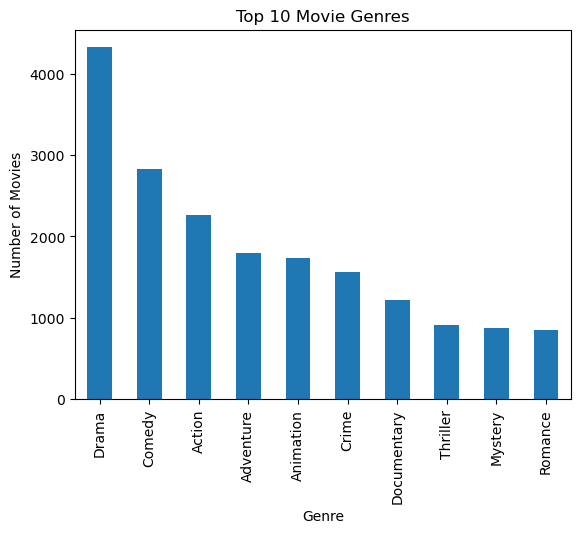

In [26]:
genre_counts.head(10).plot(
    kind='bar',
    title='Top 10 Movie Genres',
    xlabel='Genre',
    ylabel='Number of Movies'
)

In [27]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['GENRE_LIST']),
    columns=mlb.classes_,
    index=df.index
)

genre_encoded.head()

,Action,Adventure,African_History,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,1,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# Clean whitespace/newlines
df['GENRE'] = df['GENRE'].str.strip()

# Handle missing genres
df['GENRE'] = df['GENRE'].fillna('Unknown')

# Convert multiple genres into lists
df['GENRE_LIST'] = df['GENRE'].str.split(', ')

df[['GENRE', 'GENRE_LIST']].head(10)

,GENRE,GENRE_LIST
0,"Action, Horror, Thriller","[Action, Horror, Thriller]"
1,"Animation, Action, Adventure","[Animation, Action, Adventure]"
2,"Drama, Horror, Thriller","[Drama, Horror, Thriller]"
3,"Animation, Adventure, Comedy","[Animation, Adventure, Comedy]"
4,"Action, Crime, Horror","[Action, Crime, Horror]"
5,"Action, Crime, Drama","[Action, Crime, Drama]"
6,"Drama, Romance","[Drama, Romance]"
7,"Crime, Drama, Mystery","[Crime, Drama, Mystery]"
8,Comedy,[Comedy]
9,"Drama, Romance","[Drama, Romance]"


In [29]:
df['RATING'].head(10)

0    6.1
1    5.0
2    8.2
3    9.2
4    NaN
5    7.6
6    6.8
7    8.6
8    7.9
9    7.4
Name: RATING, dtype: float64

In [30]:
df['RATING'] = pd.to_numeric(df['RATING'], errors='coerce')

In [31]:
df['RATING'].dtype

dtype('float64')

In [32]:
df['RATING'].isna().sum()

np.int64(1820)

In [33]:
df['RATING'].isna().sum()

np.int64(1820)

In [34]:
df['RATING'].isna().mean() * 100

np.float64(18.201820182018203)

In [35]:
df[df['RATING'].isna()][['MOVIES', 'RATING']]

,MOVIES,RATING
4,Army of Thieves,NaN
24,He-Man and the Masters of the Universe,NaN
214,Sing 2,NaN
217,Knives Out 2,NaN
222,Don't Look Up,NaN
...,...,...
9994,The Imperfects,NaN
9995,Arcane,NaN
9996,Heart of Invictus,NaN
9997,The Imperfects,NaN


In [36]:
df['RATING'] = df['RATING'].fillna('1.1')

df['RATING'].unique()

array([6.1, 5.0, 8.2, 9.2, '1.1', 7.6, 6.8, 8.6, 7.9, 7.4, 6.0, 8.1, 6.2,
       5.4, 8.0, 7.5, 9.4, 8.3, 8.7, 8.9, 8.8, 8.5, 8.4, 6.7, 7.7, 9.0,
       5.8, 3.3, 7.8, 5.7, 6.6, 6.9, 6.5, 7.1, 5.6, 7.3, 9.1, 7.2, 6.4,
       9.3, 7.0, 6.3, 3.7, 5.5, 4.6, 4.8, 5.3, 4.7, 5.9, 5.1, 4.9, 2.7,
       4.4, 3.1, 4.5, 4.2, 3.8, 5.2, 2.8, 3.5, 4.3, 3.2, 1.1, 3.9, 4.0,
       3.4, 2.6, 3.6, 3.0, 2.5, 2.2, 2.9, 4.1, 2.1, 2.0, 2.3, 2.4, 1.8,
       9.6, 9.5, 9.7, 9.9, 9.8], dtype=object)

In [37]:
df['RATING'].dtype

dtype('O')

In [38]:
df['ONE-LINE'].unique()

array(['\nA woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic overnight flight.',
       '\nThe war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series from writer-director Kevin Smith.',
       '\nSheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to stay alive.',
       ...,
       "\nLenore urges Hector to not test Camilla's patience. Belmont and Sypha cross paths with Zamfir, a fearsome guard with a suspicious mind.",
       '\nActor Brian Tyree Henry ("Godzilla vs. Kong", "Atlanta", "The Woman in the Window"); guest co-hosts Jerry O\'Connell and Justin Baldoni;',
       "\nAs Paxton's mixed messages have Devi questioning herself, the upcoming winter dance offers a chance to determine where she stands- and what she needs."],
      dtype=object)

In [39]:
df['ONE-LINE'] = df['ONE-LINE'].str.strip()

In [40]:
df['ONE-LINE'] = (
    df['ONE-LINE']
    .astype('string')
    .str.replace('\n', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [41]:
df['ONE-LINE'].head(10)

0    A woman with a mysterious illness is forced in...
1    The war for Eternia begins again in what may b...
2    Sheriff Deputy Rick Grimes wakes up from a com...
3    An animated series that follows the exploits o...
4    A prequel, set before the events of Army of th...
5    A group of teenagers from the wrong side of th...
6    A pair of interwoven stories set in the past a...
7    By day, mild-mannered Dexter is a blood-spatte...
8    The complicated life of a modern-day first gen...
9    Seeking a fresh start, nurse practitioner Meli...
Name: ONE-LINE, dtype: string

In [42]:
df['ONE-LINE'] = df['ONE-LINE'].fillna('A man with a mysterious illness is forced in...')

In [43]:
df['Description_Length'] = df['ONE-LINE'].str.len()

In [44]:
df['Description_Word_Count'] = df['ONE-LINE'].str.split().str.len()

In [45]:
df[['ONE-LINE', 'Description_Word_Count']].head()

,ONE-LINE,Description_Word_Count
0,A woman with a mysterious illness is forced in...,22
1,The war for Eternia begins again in what may b...,25
2,Sheriff Deputy Rick Grimes wakes up from a com...,26
3,An animated series that follows the exploits o...,15
4,"A prequel, set before the events of Army of th...",37


In [46]:
# Clean ONE-LINE text
df['ONE-LINE'] = (
    df['ONE-LINE']
    .astype('string')
    .str.replace('\n', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Check result
df[['ONE-LINE']].head(10)

,ONE-LINE
0,A woman with a mysterious illness is forced in...
1,The war for Eternia begins again in what may b...
2,Sheriff Deputy Rick Grimes wakes up from a com...
3,An animated series that follows the exploits o...
4,"A prequel, set before the events of Army of th..."
5,A group of teenagers from the wrong side of th...
6,A pair of interwoven stories set in the past a...
7,"By day, mild-mannered Dexter is a blood-spatte..."
8,The complicated life of a modern-day first gen...
9,"Seeking a fresh start, nurse practitioner Meli..."


In [47]:
df['ONE-LINE'].dtype

string[python]